# Plotting with wompywompy

This mirrors the [R `wompwomp` package's plotting vignette](https://github.com/pachterlab/wompwomp/blob/main/vignettes/plotting.Rmd): the same toy tissue/cluster dataset, plotted unsorted, sorted-but-uncolored, and sorted-and-colored.

Note: this is **not** aiming for pixel-identical output — R's version uses ggplot2/ggalluvial, this uses matplotlib, and the two render very differently. The point of comparison is the underlying data (sort order, color/cluster groupings, crossing-objective number), not plot styling.

In [1]:
import pandas as pd

from wompywompy.wompwomp import plot_alluvial, determine_crossing_edges, data_sort

In [2]:
df = pd.DataFrame({
    "tissue": (
        ["BRAIN"] * 3
        + ["STOMACH"] * 6
        + ["HEART"] * 7
        + ["T CELL"] * 2
        + ["B CELL"] * 9
    ),
    "cluster": (
        [1, 1, 2]
        + [1, 2, 2, 2, 2, 2]
        + [1, 3, 3, 3, 3, 3, 3]
        + [4, 4]
        + [4, 4, 4, 4, 4, 4, 4, 4, 4]
    ),
})
graphing_columns = ["tissue", "cluster"]

## Unsorted, uncolored (default per-category colors)

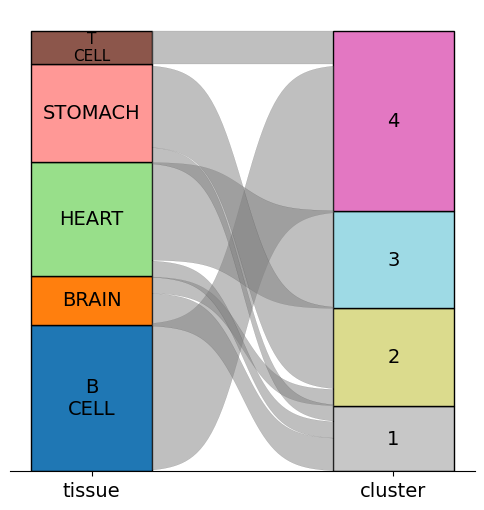

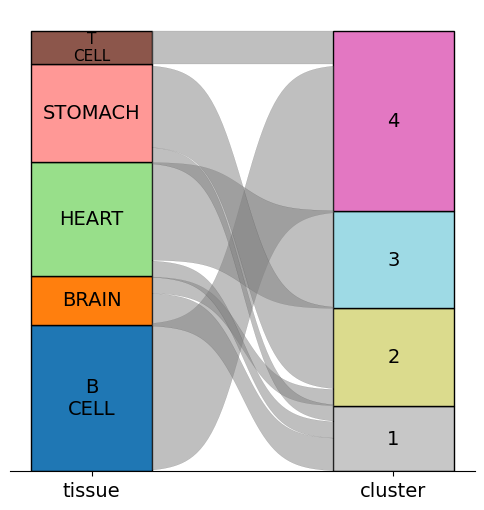

In [3]:
fig_unsorted, ax_unsorted = plot_alluvial(
    df=df,
    graphing_columns=graphing_columns,
    sorting_algorithm=None,
    match_colors=False,
    color_boxes=True,
    include_labels_in_boxes=True,
)
fig_unsorted

## Sorted (tsp), uncolored

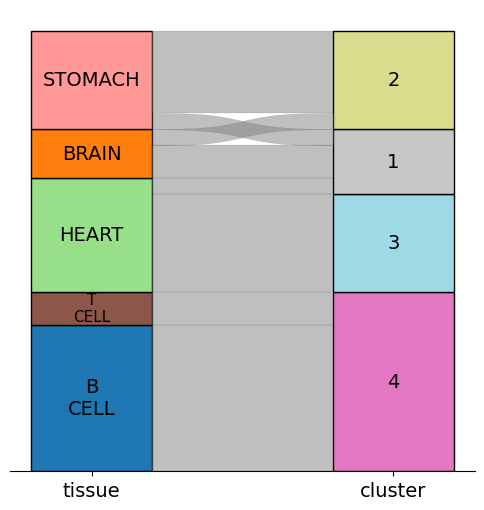

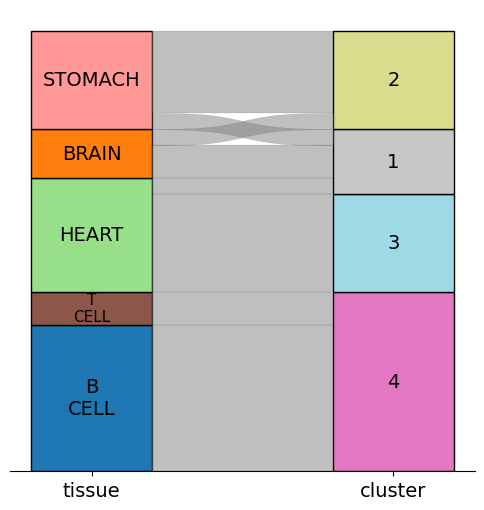

In [4]:
fig_sorted, ax_sorted = plot_alluvial(
    df=df,
    graphing_columns=graphing_columns,
    sorting_algorithm="tsp",
    match_colors=False,
    color_boxes=True,
    include_labels_in_boxes=True,
)
fig_sorted

## Sorted (tsp), colored by cluster agreement (leiden)

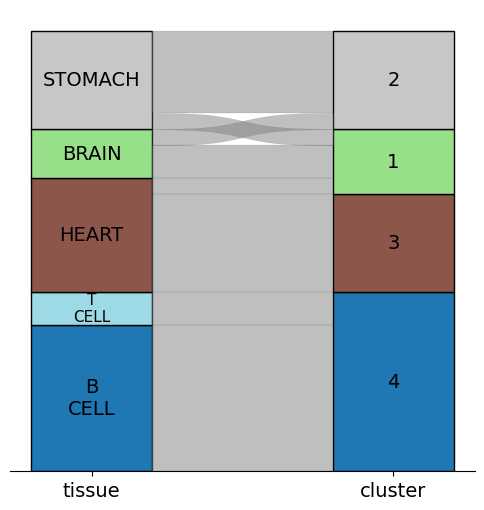

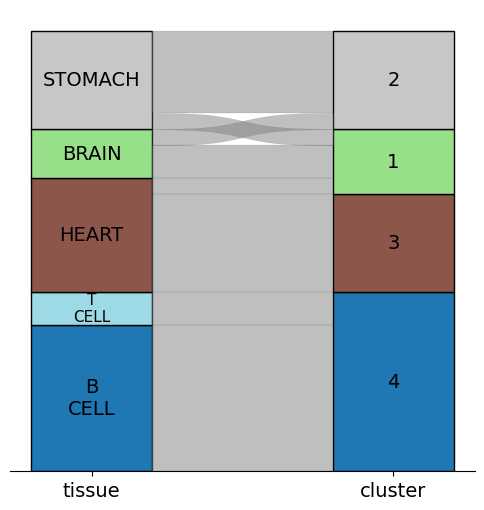

In [5]:
fig_sorted_colored, ax_sorted_colored = plot_alluvial(
    df=df,
    graphing_columns=graphing_columns,
    sorting_algorithm="tsp",
    match_colors=True,
    coloring_algorithm="advanced",
    coloring_algorithm_advanced_option="leiden",
    include_labels_in_boxes=True,
)
fig_sorted_colored

## Crossing objective for the sorted order

In [6]:
clus_df_gather = (
    df.astype({col: str for col in graphing_columns})
    .groupby(graphing_columns, as_index=False)
    .size()
    .rename(columns={"size": "value"})
)
graphing_columns_sorted, order_dict = data_sort(
    df=clus_df_gather,
    graphing_columns=graphing_columns,
    column_weights="value",
    sorting_algorithm="tsp",
)
crossing_objective = determine_crossing_edges(
    clus_df_gather,
    graphing_columns=graphing_columns_sorted,
    order_dict=order_dict,
    col_weights="value",
)
crossing_objective

1